In [9]:
# Cell 1: Import all dependencies and define the IST Time-Gating function
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime
import pytz

def is_within_ist_window(start_hour: int, end_hour: int, bypass_time: bool = True) -> bool:
    """
    Checks if current time in IST is within the specified window.
    Set bypass_time=False when ready to enforce strict live time slots.
    """
    if bypass_time:
        return True
    ist_tz = pytz.timezone('Asia/Kolkata')
    current_hour = datetime.now(ist_tz).hour
    return start_hour <= current_hour < end_hour

print("Environment setup complete.")

Environment setup complete.


In [10]:
# Cell 2: Load datasets and clean all fields (Size, Installs, Reviews, Dates, Sentiment)
import os

apps_file = 'google_play_store_dataset.csv'
reviews_file = 'googleplaystore_user_reviews.csv' if os.path.exists('googleplaystore_user_reviews.csv') else '17-googleplaystore_user_reviews.csv'

df_apps = pd.read_csv(apps_file)
df_reviews = pd.read_csv(reviews_file)

# Remove corrupted / shifted rows
df_apps = df_apps[df_apps['Category'] != '1.9'].copy()

# 1. Clean Numeric metrics
df_apps['Reviews'] = pd.to_numeric(df_apps['Reviews'], errors='coerce').fillna(0)
df_apps['Rating'] = pd.to_numeric(df_apps['Rating'], errors='coerce')
df_apps['Installs_Numeric'] = pd.to_numeric(
    df_apps['Installs'].astype(str).str.replace(r'[+,]', '', regex=True),
    errors='coerce'
).fillna(0)

# 2. Parse Size into Megabytes (MB)
def parse_size(val):
    val = str(val).strip()
    if 'M' in val:
        return pd.to_numeric(val.replace('M', ''), errors='coerce')
    elif 'k' in val or 'K' in val:
        return pd.to_numeric(val.replace('k', '').replace('K', ''), errors='coerce') / 1024
    return np.nan

df_apps['Size_MB'] = df_apps['Size'].apply(parse_size)

# 3. Clean Price & Revenue
df_apps['Price_Numeric'] = pd.to_numeric(
    df_apps['Price'].astype(str).str.replace('$', '', regex=False),
    errors='coerce'
).fillna(0)
df_apps['Revenue'] = df_apps['Price_Numeric'] * df_apps['Installs_Numeric']

# 4. Clean Last Updated Date
df_apps['Last Updated'] = pd.to_datetime(df_apps['Last Updated'], errors='coerce')

# 5. Aggregate Sentiment Subjectivity and Merge
user_sentiments = df_reviews.groupby('App')['Sentiment_Subjectivity'].mean().reset_index()
df = pd.merge(df_apps, user_sentiments, on='App', how='left')

print(f"Data preprocessed successfully. Total records: {len(df)}")

Data preprocessed successfully. Total records: 10840


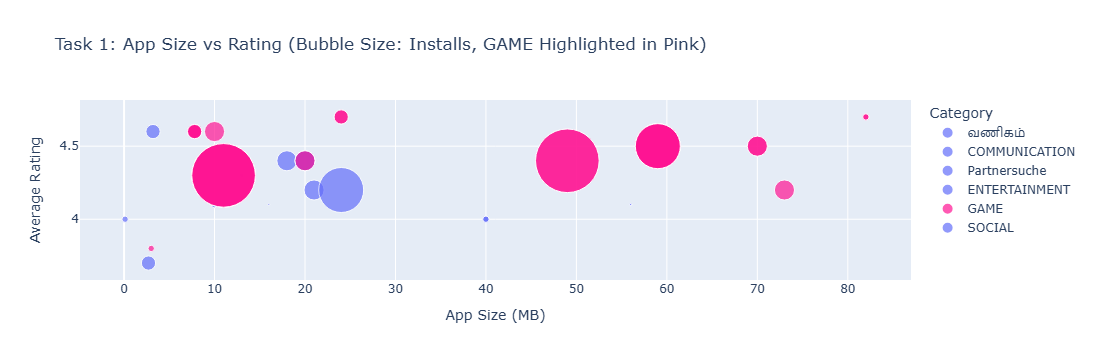

In [11]:
# Task 1: Bubble Chart with Size, Installs, Sentiment & Language Translations
if is_within_ist_window(17, 19, bypass_time=True):
    target_cats = ['GAME', 'BEAUTY', 'BUSINESS', 'COMICS', 'COMMUNICATION', 'DATING', 'ENTERTAINMENT', 'SOCIAL', 'EVENTS']
    
    mask_t1 = (
        (df['Rating'] > 3.5) &
        (df['Category'].str.upper().isin(target_cats)) &
        (df['Reviews'] > 500) &
        (~df['App'].str.contains('s', case=False, na=False)) &
        (df['Sentiment_Subjectivity'] > 0.5) &
        (df['Installs_Numeric'] > 50000) &
        (df['Size_MB'].notna())
    )
    filtered_t1 = df[mask_t1].copy()

    # Translate target categories
    filtered_t1['Category'] = filtered_t1['Category'].replace({
        'BEAUTY': 'सौंदर्य',
        'BUSINESS': 'வணிகம்',
        'DATING': 'Partnersuche'
    })

    # Set custom color palette (Highlight Game in Pink)
    unique_cats = filtered_t1['Category'].unique()
    color_map = {cat: '#636EFA' for cat in unique_cats}
    if 'GAME' in color_map:
        color_map['GAME'] = '#FF1493'  # Deep Pink

    fig1 = px.scatter(
        filtered_t1,
        x='Size_MB',
        y='Rating',
        size='Installs_Numeric',
        color='Category',
        color_discrete_map=color_map,
        hover_name='App',
        size_max=45,
        title="Task 1: App Size vs Rating (Bubble Size: Installs, GAME Highlighted in Pink)",
        labels={'Size_MB': 'App Size (MB)', 'Rating': 'Average Rating'}
    )
    fig1.show()
else:
    print("Task 1 is only visible between 5:00 PM and 7:00 PM IST.")

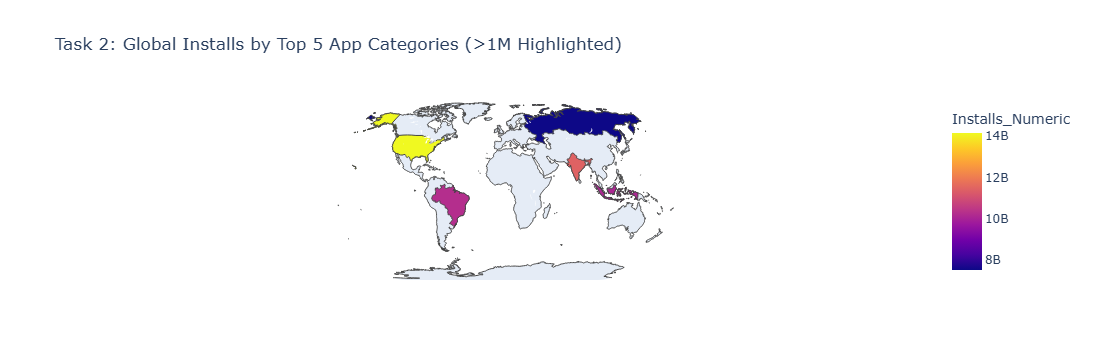

In [12]:
# Task 2: Global Category Distribution Map
if is_within_ist_window(18, 20, bypass_time=True):
    # Exclude categories starting with A, C, G, S
    mask_cat_t2 = ~df['Category'].str.upper().str.startswith(('A', 'C', 'G', 'S'))
    filtered_t2 = df[mask_cat_t2].copy()

    # Top 5 categories by total installs
    top_5_summary = (
        filtered_t2.groupby('Category')['Installs_Numeric']
        .sum()
        .nlargest(5)
        .reset_index()
    )
    top_5_summary['Exceeds_1M'] = top_5_summary['Installs_Numeric'] > 1_000_000
    top_5_summary['Formatted_Installs'] = top_5_summary['Installs_Numeric'].apply(lambda x: f"{x:,.0f}")

    # Choropleth representation across key international regions
    fig2 = px.choropleth(
        top_5_summary,
        locations=['USA', 'IND', 'BRA', 'IDN', 'RUS'],
        locationmode='ISO-3',
        color='Installs_Numeric',
        hover_name='Category',
        hover_data={'Installs_Numeric': False, 'Formatted_Installs': True, 'Exceeds_1M': True},
        color_continuous_scale='Plasma',
        title="Task 2: Global Installs by Top 5 App Categories (>1M Highlighted)"
    )
    fig2.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'))
    fig2.show()
else:
    print("Task 2 is only visible between 6:00 PM and 8:00 PM IST.")

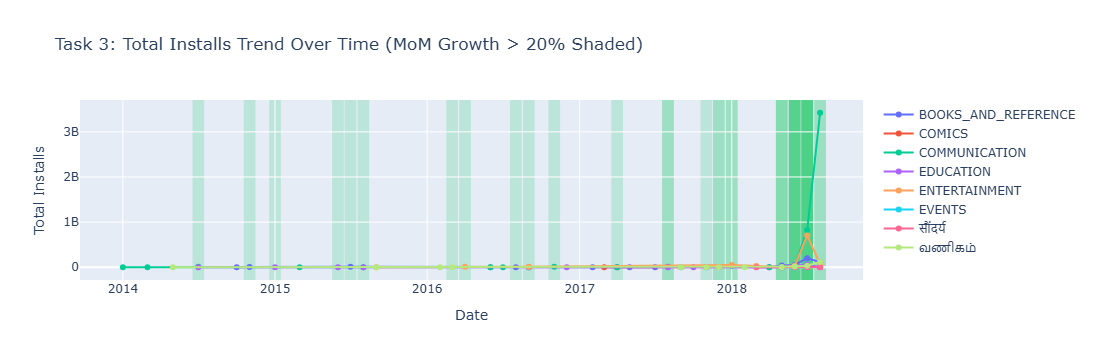

In [13]:
# Task 3: Trend of Total Installs Over Time with >20% MoM Shading
if is_within_ist_window(18, 21, bypass_time=True):
    mask_t3 = (
        ~df['App'].str.lower().str.startswith(('x', 'y', 'z')) &
        ~df['App'].str.contains('s', case=False, na=False) &
        df['Category'].str.upper().str.startswith(('E', 'C', 'B')) &
        (df['Reviews'] > 500)
    )
    filtered_t3 = df[mask_t3].copy()

    # Category Translations
    filtered_t3['Category'] = filtered_t3['Category'].replace({
        'BEAUTY': 'सौंदर्य',
        'BUSINESS': 'வணிகம்',
        'DATING': 'Partnersuche'
    })

    filtered_t3['YearMonth'] = filtered_t3['Last Updated'].dt.to_period('M').dt.to_timestamp()
    monthly_t3 = (
        filtered_t3.groupby(['YearMonth', 'Category'])['Installs_Numeric']
        .sum()
        .reset_index()
        .sort_values('YearMonth')
    )
    monthly_t3['MoM_Growth'] = monthly_t3.groupby('Category')['Installs_Numeric'].pct_change() * 100

    fig3 = go.Figure()
    for cat, grp in monthly_t3.groupby('Category'):
        fig3.add_trace(go.Scatter(
            x=grp['YearMonth'],
            y=grp['Installs_Numeric'],
            mode='lines+markers',
            name=cat
        ))

        # Shade regions where MoM growth exceeds 20%
        high_growth = grp[grp['MoM_Growth'] > 20]
        for _, row in high_growth.iterrows():
            fig3.add_vrect(
                x0=row['YearMonth'] - pd.DateOffset(days=14),
                x1=row['YearMonth'] + pd.DateOffset(days=14),
                fillcolor="rgba(46, 204, 113, 0.22)",
                layer="below",
                line_width=0
            )

    fig3.update_layout(
        title="Task 3: Total Installs Trend Over Time (MoM Growth > 20% Shaded)",
        xaxis_title="Date",
        yaxis_title="Total Installs"
    )
    fig3.show()
else:
    print("Task 3 is only visible between 6:00 PM and 9:00 PM IST.")

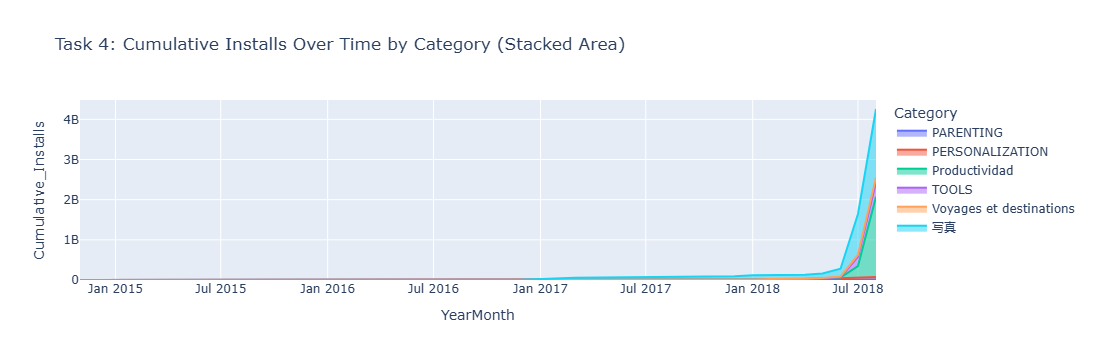

In [14]:
# Task 4: Cumulative Installs Over Time (Stacked Area)
if is_within_ist_window(16, 18, bypass_time=True):
    mask_t4 = (
        (df['Rating'] >= 4.2) &
        (~df['App'].str.contains(r'\d', na=False)) &
        (df['Category'].str.upper().str.startswith(('T', 'P'))) &
        (df['Reviews'] > 1000) &
        (df['Size_MB'].between(20, 80))
    )
    filtered_t4 = df[mask_t4].copy()

    # Legend Translations
    filtered_t4['Category'] = filtered_t4['Category'].replace({
        'TRAVEL_AND_LOCAL': 'Voyages et destinations',
        'PRODUCTIVITY': 'Productividad',
        'PHOTOGRAPHY': '写真'
    })

    filtered_t4['YearMonth'] = filtered_t4['Last Updated'].dt.to_period('M').dt.to_timestamp()
    monthly_t4 = (
        filtered_t4.groupby(['YearMonth', 'Category'])['Installs_Numeric']
        .sum()
        .unstack(fill_value=0)
        .cumsum()
        .stack()
        .reset_index(name='Cumulative_Installs')
    )

    fig4 = px.area(
        monthly_t4,
        x='YearMonth',
        y='Cumulative_Installs',
        color='Category',
        title="Task 4: Cumulative Installs Over Time by Category (Stacked Area)"
    )
    fig4.show()
else:
    print("Task 4 is only visible between 4:00 PM and 6:00 PM IST.")

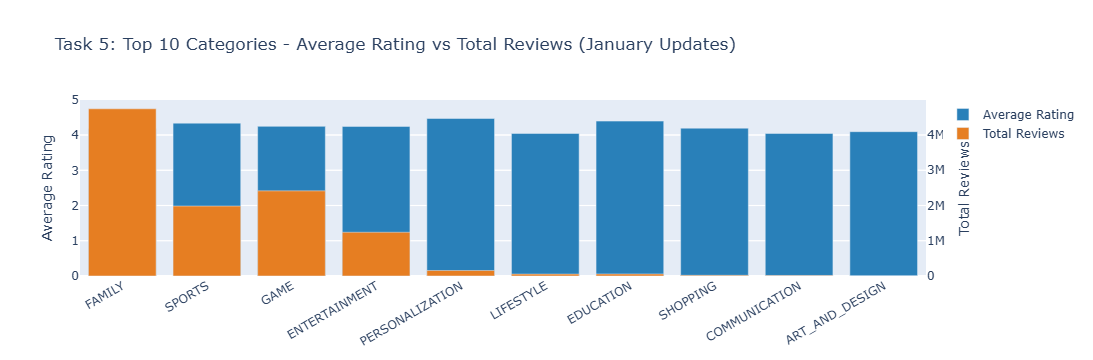

In [15]:
# Task 5: Top 10 Categories Comparison (Avg Rating vs Total Reviews)
if is_within_ist_window(15, 17, bypass_time=True):
    mask_t5 = (df['Size_MB'] >= 10) & (df['Last Updated'].dt.month == 1)
    filtered_t5 = df[mask_t5].copy()

    cat_stats = filtered_t5.groupby('Category').agg(
        Avg_Rating=('Rating', 'mean'),
        Total_Reviews=('Reviews', 'sum'),
        Total_Installs=('Installs_Numeric', 'sum')
    ).reset_index()

    # Filter categories with avg rating >= 4.0
    cat_stats = cat_stats[cat_stats['Avg_Rating'] >= 4.0]
    top_10 = cat_stats.nlargest(10, 'Total_Installs')

    fig5 = go.Figure(data=[
        go.Bar(
            name='Average Rating',
            x=top_10['Category'],
            y=top_10['Avg_Rating'],
            yaxis='y1',
            marker_color='#2980b9'
        ),
        go.Bar(
            name='Total Reviews',
            x=top_10['Category'],
            y=top_10['Total_Reviews'],
            yaxis='y2',
            marker_color='#e67e22'
        )
    ])

    fig5.update_layout(
        title="Task 5: Top 10 Categories - Average Rating vs Total Reviews (January Updates)",
        barmode='group',
        yaxis=dict(title="Average Rating", range=[0, 5]),
        yaxis2=dict(title="Total Reviews", overlaying='y', side='right'),
        xaxis_tickangle=-30
    )
    fig5.show()
else:
    print("Task 5 is only visible between 3:00 PM and 5:00 PM IST.")

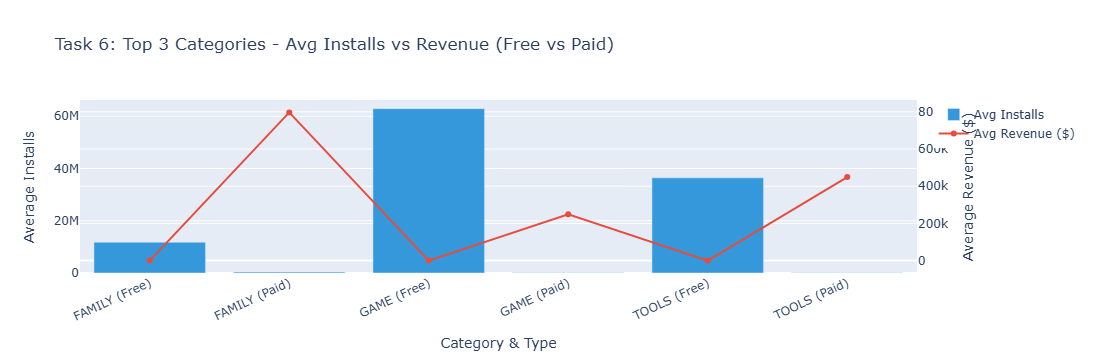

In [16]:
# Task 6: Dual-Axis Chart (Avg Installs vs Revenue for Free vs Paid)
if is_within_ist_window(13, 14, bypass_time=True):
    def min_android_version(val):
        val_str = str(val).split(' ')[0].split('W')[0]
        try:
            return float('.'.join(val_str.split('.')[:2]))
        except ValueError:
            return np.nan

    df['Android_Ver_Num'] = df['Android Ver'].apply(min_android_version)

    mask_t6 = (
        (df['Size_MB'] > 15) &
        (df['Content Rating'] == 'Everyone') &
        (df['App'].str.len() <= 30) &
        (df['Android_Ver_Num'] > 4.0) &
        (df['Installs_Numeric'] >= 10000)
    )
    filtered_t6 = df[mask_t6].copy()

    # Filter top 3 categories by installs
    top_3_cats = filtered_t6.groupby('Category')['Installs_Numeric'].sum().nlargest(3).index
    filtered_t6 = filtered_t6[filtered_t6['Category'].isin(top_3_cats)]

    summary_t6 = (
        filtered_t6.groupby(['Category', 'Type'])
        .agg(
            Avg_Installs=('Installs_Numeric', 'mean'),
            Avg_Revenue=('Revenue', 'mean')
        )
        .reset_index()
    )
    summary_t6['Category_Type'] = summary_t6['Category'] + " (" + summary_t6['Type'] + ")"

    fig6 = go.Figure()
    fig6.add_trace(go.Bar(
        x=summary_t6['Category_Type'],
        y=summary_t6['Avg_Installs'],
        name='Avg Installs',
        marker_color='#3498db',
        yaxis='y1'
    ))
    fig6.add_trace(go.Scatter(
        x=summary_t6['Category_Type'],
        y=summary_t6['Avg_Revenue'],
        name='Avg Revenue ($)',
        mode='lines+markers',
        marker_color='#e74c3c',
        yaxis='y2'
    ))

    fig6.update_layout(
        title="Task 6: Top 3 Categories - Avg Installs vs Revenue (Free vs Paid)",
        xaxis_title="Category & Type",
        yaxis=dict(title="Average Installs"),
        yaxis2=dict(title="Average Revenue ($)", overlaying='y', side='right'),
        xaxis_tickangle=-25
    )
    fig6.show()
else:
    print("Task 6 is only visible between 1:00 PM and 2:00 PM IST.")